Group Names: Andrew Mankin, Ryan 

Delete the .gz after processing data

Negative Dataset parts downloaded: covid19_neg_partab, covid19_neg_partae, covid19_neg_partaf, covid19_neg_partah,covid19_neg_partai

Positive Dataset parts downloaded: bimcv_covid19_posi_subjects_1, bimcv_covid19_posi_subjects_2, bimcv_covid19_posi_subjects_3,bimcv_covid19_posi_subjects_4,bimcv_covid19_posi_subjects_5,bimcv_covid19_posi_subjects_6

In [15]:
import json
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img
import re


# Preprocessing
**NOTE**: Put positive samples in `positive/` and negative samples in `negative/`

BIMCV dataset structure is as follows:

- top level: `sub-SXXXXXX/`
    - `ses-XXXXXX/` - scan + metadata
    - 

In [83]:
IMAGE_DIR = "./dataset/images"
JSON_DIR = "./dataset/metadata"
os.makedirs(JSON_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

IMAGE_TYPE_IDENTIFIER = '00280004'

In [108]:
def preprocess(start_dir, label):
    subjects = []
    images = []
    image_types = []
    sessions = []
    labels = []
    for root, _, files in os.walk(start_dir):
        for f in files:
            if f.endswith(".png"):
                json_file = os.path.join(root, f.replace("png", "json"))
                if not os.path.exists(json_file): continue
                subject = re.search(r"sub-S\d+", f).group()
                subjects.append(subject)
                session = re.search(r"ses-E\d+", f).group()
                sessions.append(session)
                image = os.path.join(root, f)
                images.append(image)
                with open(json_file) as file:
                    metadata = json.load(file)
                    image_type = metadata[IMAGE_TYPE_IDENTIFIER]['Value'][0]
                    image_types.append(image_type)
                labels.append(label)
    return pd.DataFrame(data={'subject': subjects, 'image_path': images, 'image_type': image_types, 'session': sessions, 'label': labels})

In [109]:
df = pd.concat([preprocess("./positive", True), preprocess("./negative", False)])
print(df.shape)
df.head()

(166, 5)


,subject,image_path,image_type,session,label
0,sub-S330013,./positive/sub-S330013/ses-E61063/mod-rx/sub-S...,MONOCHROME2,ses-E61063,True
1,sub-S326512,./positive/sub-S326512/ses-E53169/mod-rx/sub-S...,MONOCHROME2,ses-E53169,True
2,sub-S326512,./positive/sub-S326512/ses-E53169/mod-rx/sub-S...,MONOCHROME2,ses-E53169,True
3,sub-S333838,./positive/sub-S333838/ses-E70937/mod-rx/sub-S...,MONOCHROME2,ses-E70937,True
4,sub-S333838,./positive/sub-S333838/ses-E70937/mod-rx/sub-S...,MONOCHROME2,ses-E70937,True


In [112]:
df.to_csv('data.csv')

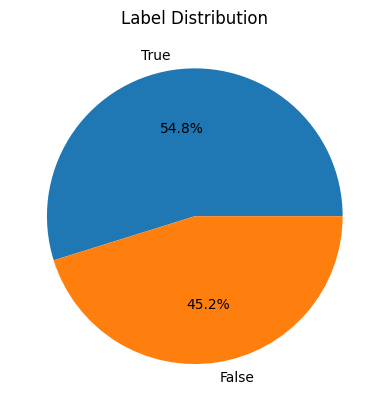

In [111]:
counts = df["label"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Label Distribution")
plt.show()